In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from wordcloud import WordCloud


df = pd.read_excel('final_social_media_data.xlsx')

df_x = df[df['platform'] == 'X'].copy()
df_insta = df[df['platform'] == 'Instagram'].copy()

print("✅ Data Loaded and Filtered by Platform.")
print(f"Total Records for X: {len(df_x)}")
print(f"Total Records for Instagram: {len(df_insta)}")

✅ Data Loaded and Filtered by Platform.
Total Records for X: 845
Total Records for Instagram: 928



[STEP 1] Analyzing X: Text Layer


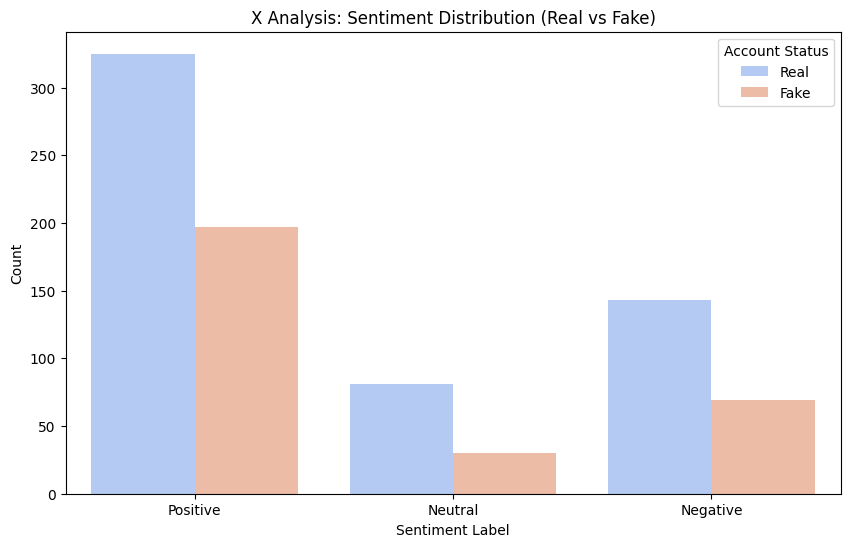

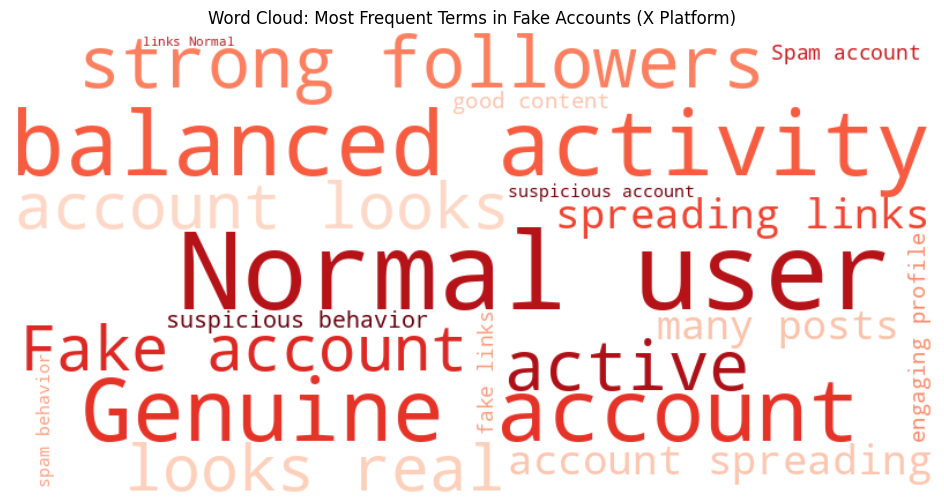

/tmp/ipykernel_1691/3419789865.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_x, x='is_fake', y='spam_comments_rate', palette='Blues')


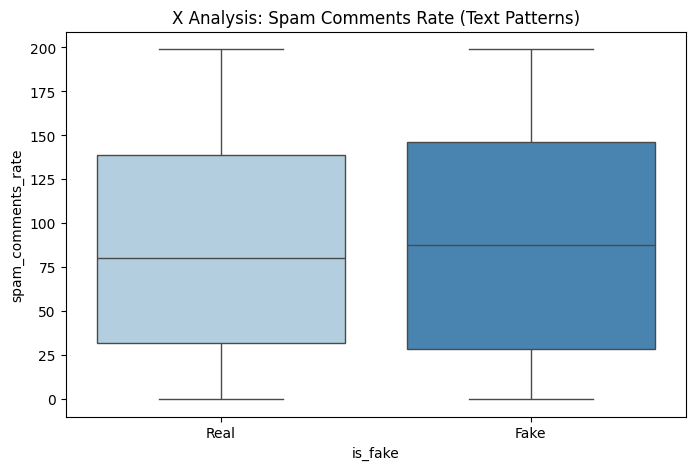

In [ ]:
# SECTION 1: X - Text Layer Analysis
# Using 'text', 'sentiment_label', and 'spam_comments_rate'
print("\n[STEP 1] Analyzing X: Text Layer")

# Plot 1: Sentiment Distribution Comparison
plt.figure(figsize=(10, 6))
sns.countplot(data=df_x, x='sentiment_label', hue='is_fake', palette='coolwarm')
plt.title('X Analysis: Sentiment Distribution (Real vs Fake)')
plt.xlabel('Sentiment Label')
plt.ylabel('Count')
plt.legend(title='Account Status', labels=['Real', 'Fake'])
plt.savefig('/content/img5.png')
plt.show()
plt.close()

# Plot 2: Text Content Analysis: Word Cloud for Fake Accounts
fake_texts = " ".join(df_x[df_x['is_fake'] == 1]['text'].astype(str))
wordcloud = WordCloud(width=800, height=400, background_color='white', colormap='Reds').generate(fake_texts)

plt.figure(figsize=(12, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud: Most Frequent Terms in Fake Accounts (X Platform)')
plt.savefig('/content/img6.png')
plt.show()
plt.close()

# Plot 3: Spam Rate Analysis
plt.figure(figsize=(8, 5))
sns.boxplot(data=df_x, x='is_fake', y='spam_comments_rate', palette='Blues')
plt.title('X Analysis: Spam Comments Rate (Text Patterns)')
plt.xticks([0, 1], ['Real', 'Fake'])
plt.savefig('/content/img7.png')
plt.show()
plt.close()


[STEP 2] Analyzing Instagram: Network, Action and Hyperlinks


/tmp/ipykernel_1691/504824968.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_insta, x='is_fake', y='follower_following_ratio', palette='Greens')


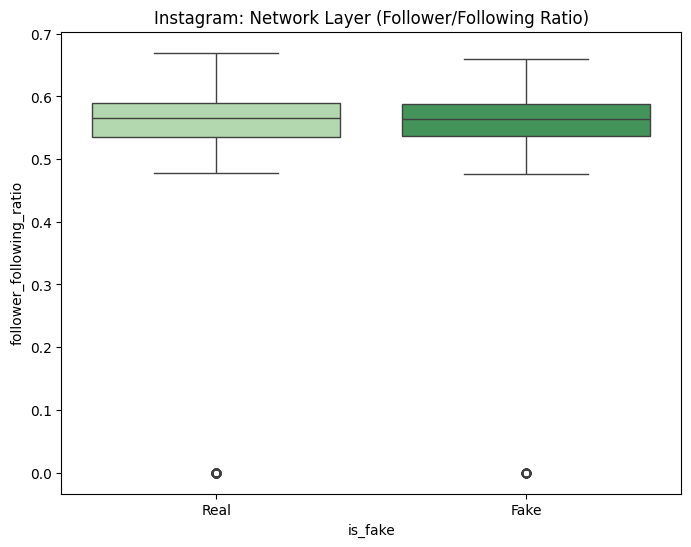

/tmp/ipykernel_1691/504824968.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_insta, x='is_fake', y='posts_per_day', palette='Oranges')


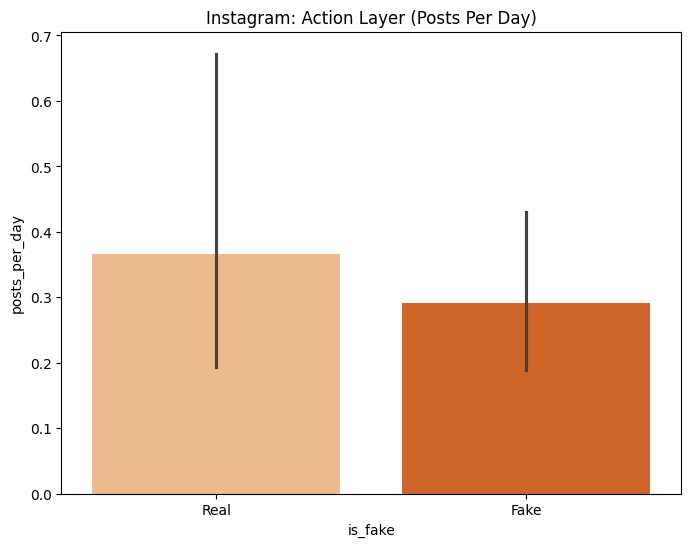

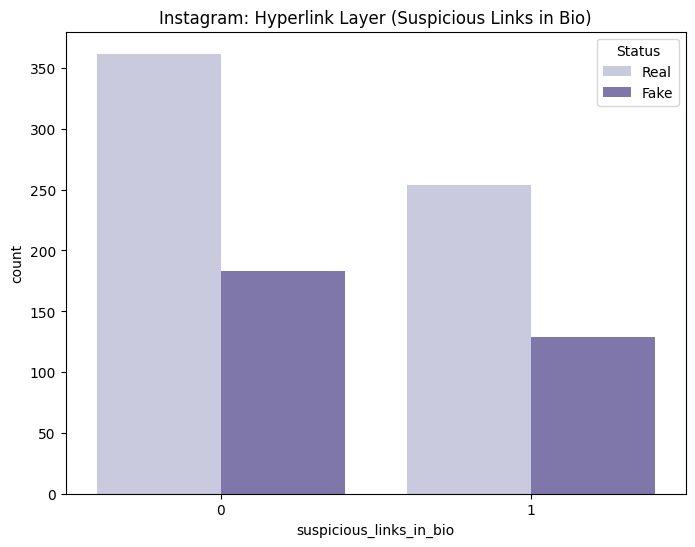

In [ ]:
# SECTION 2: Instagram - Network, Action, and Hyperlink Layers
print("\n[STEP 2] Analyzing Instagram: Network, Action and Hyperlinks")

# Plot 4: Network Layer (Follower/Following Ratio)
plt.figure(figsize=(8, 6))
sns.boxplot(data=df_insta, x='is_fake', y='follower_following_ratio', palette='Greens')
plt.title('Instagram: Network Layer (Follower/Following Ratio)')
plt.xticks([0, 1], ['Real', 'Fake'])
plt.savefig('/content/img2.png')
plt.show()
plt.close()

# Plot 5: Action Layer (Daily Activity)
plt.figure(figsize=(8, 6))
sns.barplot(data=df_insta, x='is_fake', y='posts_per_day', palette='Oranges')
plt.title('Instagram: Action Layer (Posts Per Day)')
plt.xticks([0, 1], ['Real', 'Fake'])
plt.savefig('/content/img3.png')
plt.show()
plt.close()

# Plot 6: Hyperlink Layer (Link Security)
plt.figure(figsize=(8, 6))
sns.countplot(data=df_insta, x='suspicious_links_in_bio', hue='is_fake', palette='Purples')
plt.title('Instagram: Hyperlink Layer (Suspicious Links in Bio)')
plt.legend(title='Status', labels=['Real', 'Fake'])
plt.savefig('/content/img4.png')
plt.show()
plt.close()


[STEP 3] Integration: Multi-Layer Correlation Analysis


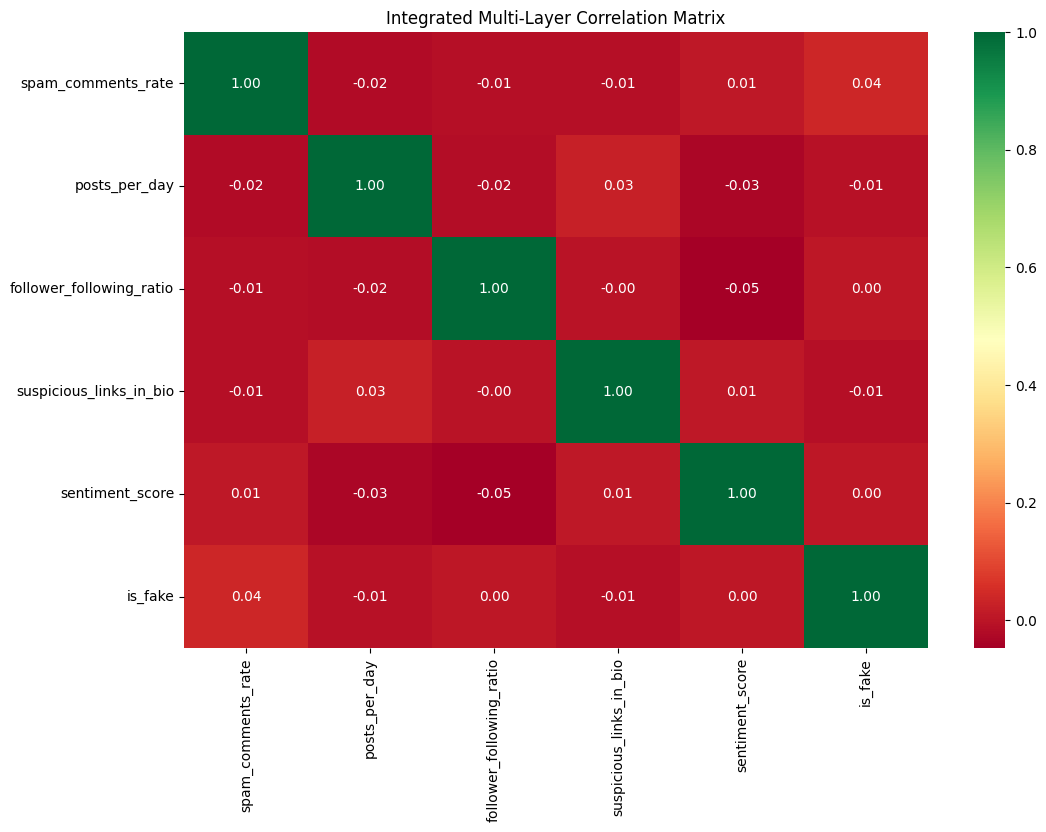


All analyses completed successfully.


In [ ]:
# SECTION 3: Integration (Cross-Layer Correlation)
print("\n[STEP 3] Integration: Multi-Layer Correlation Analysis")
# We integrate the layers into a single correlation heatmap
plt.figure(figsize=(12, 8))
core_features = [
    'spam_comments_rate',        # Text Layer (from X context)
    'posts_per_day',             # Action Layer (from Insta context)
    'follower_following_ratio',  # Network Layer (from Insta context)
    'suspicious_links_in_bio',   # Hyperlink Layer (from Insta context)
    'sentiment_score',           # Integrated Sentiment
    'is_fake'                    # Target Variable
]
sns.heatmap(df[core_features].corr(), annot=True, cmap='RdYlGn', fmt=".2f")
plt.title('Integrated Multi-Layer Correlation Matrix')
plt.savefig('/content/img1.png')
plt.show()
plt.close()

print("\nAll analyses completed successfully.")